In [94]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

In [ ]:


segment_df = pd.read_parquet(
    "../data/processed/segment_df.parquet"
)

trip_df = pd.read_parquet(
    "../data/processed/trip_df.parquet"
)

edge_weights = pd.read_parquet(
    "../data/processed/edge_weights.parquet"
)

print(segment_df.shape)
print(trip_df.shape)
print(edge_weights.shape)

(18947, 28)
(9691, 12)
(3246, 5)


In [ ]:
G = nx.DiGraph()

for _, row in edge_weights.iterrows():

    G.add_edge(
        row["source_center"],
        row["destination_center"],
        delay_ratio=row["edge_weight"]
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 1561
Edges: 2331


In [63]:
list(G.edges(data=True))[:5]

[('IND000000AAL', 'IND411033AAA', {'delay_ratio': 2.08}),
 ('IND411033AAA', 'IND000000AAL', {'delay_ratio': 2.5092592592592595}),
 ('IND411033AAA', 'IND000000ACB', {'delay_ratio': 1.7310344827586206}),
 ('IND411033AAA', 'IND400072AAB', {'delay_ratio': 1.9029126213592233}),
 ('IND411033AAA', 'IND403726AAA', {'delay_ratio': 2.023076923076923})]

In [64]:
edge_weights.head()

,source_center,destination_center,route_type,time_bin,edge_weight
0,IND000000AAL,IND411033AAA,Carting,evening_peak,2.083333
1,IND000000AAL,IND411033AAA,Carting,midday,2.600000
2,IND000000AAL,IND411033AAA,Carting,morning_peak,3.384615
3,IND000000AAL,IND411033AAA,Carting,overnight,2.080000
4,IND000000AAS,IND783370AAC,FTL,evening_peak,2.666667


In [65]:
Q1_ew = edge_weights['edge_weight'].quantile(0.25)
Q3_ew = edge_weights['edge_weight'].quantile(0.75)
IQR_ew = Q3_ew - Q1_ew
upper_ew = Q3_ew + 1.5 * IQR_ew

print(f"Q1: {Q1_ew:.2f}")
print(f"Q3: {Q3_ew:.2f}")
print(f"IQR: {IQR_ew:.2f}")
print(f"Upper bound: {upper_ew:.2f}")
print(f"Corridors that would be removed: {(edge_weights['edge_weight'] > upper_ew).sum()}")
print(f"Corridors that would remain: {(edge_weights['edge_weight'] <= upper_ew).sum()}")

Q1: 1.68
Q3: 2.47
IQR: 0.79
Upper bound: 3.65
Corridors that would be removed: 105
Corridors that would remain: 3141


In [66]:
edge_weights = edge_weights[edge_weights['edge_weight'] <= upper_ew].reset_index(drop=True)
print(edge_weights.shape)
print(edge_weights['edge_weight'].max())

(3141, 5)
3.6263736263736264


In [ ]:

graph_edges = (
    edge_weights
    .groupby(['source_center', 'destination_center'], as_index=False)['edge_weight']
    .median()
)

G = nx.DiGraph()

for _, row in graph_edges.iterrows():
    G.add_edge(
        row['source_center'],
        row['destination_center'],
        weight=row['edge_weight']
    )

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Sample edges:")
print(list(G.edges(data=True))[:3])

Nodes: 1541
Edges: 2270
Sample edges:
[('IND000000AAL', 'IND411033AAA', {'weight': 2.341666666666667}), ('IND411033AAA', 'IND000000AAL', {'weight': 2.5092592592592595}), ('IND411033AAA', 'IND000000ACB', {'weight': 1.7136185563011521})]


In [68]:
# average dwell time per hub
dwell = segment_df.groupby('source_center')['segment_actual_time'].mean().to_dict()

# inbound volume per hub
inbound_vol = segment_df.groupby('destination_center').size().to_dict()

# average delay ratio of connected corridors per hub
avg_delay = segment_df.groupby('source_center')['delay_ratio'].mean().to_dict()

for node in G.nodes():
    G.nodes[node]['avg_dwell_time'] = dwell.get(node, 0)
    G.nodes[node]['inbound_volume'] = inbound_vol.get(node, 0)
    G.nodes[node]['avg_delay_ratio'] = avg_delay.get(node, 0)

# verify one node
sample_node = list(G.nodes())[0]
print(f"Sample node: {sample_node}")
print(G.nodes[sample_node])

Sample node: IND000000AAL
{'avg_dwell_time': 47.57142857142857, 'inbound_volume': 14, 'avg_delay_ratio': 2.8454185247120027}


## Node Features
These features are added for each node
| Feature | Description |
|----------|------------|
| `avg_dwell_time` | Average time vehicles spend waiting at a hub before departure. Higher values indicate potential operational bottlenecks. |
| `inbound_volume` | Number of historical arrivals at a hub, computed from incoming corridors. Higher values indicate greater traffic and congestion risk. |
| `avg_delay_ratio` | Average corridor delay ratio for shipments originating from a hub. Higher values indicate greater operational friction and persistent delays. |

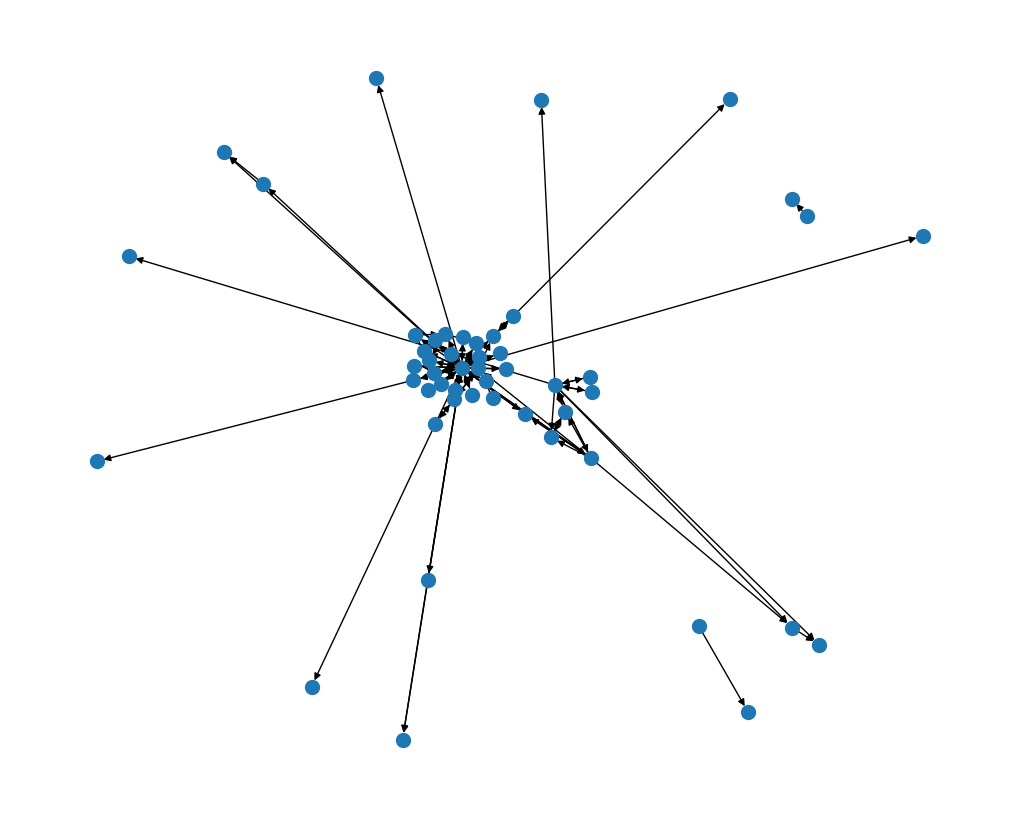

In [69]:
import matplotlib.pyplot as plt
sample_nodes = list(G.nodes())[:50]

H = G.subgraph(sample_nodes)

plt.figure(figsize=(10,8))
nx.draw(
    H,
    node_size=100,
    with_labels=False
)
plt.show()

In [70]:
delayed_source = set(
    graph_edges[graph_edges['edge_weight'] > 1.20]['source_center']
)
delayed_dest = set(
    graph_edges[graph_edges['edge_weight'] > 1.20]['destination_center']
)

delay_count = {}
for node in G.nodes():
    count = 0
    for u, v, data in G.edges(node, data=True):
        if data['weight'] > 1.20:
            count += 1
    for u, v, data in G.in_edges(node, data=True):
        if data['weight'] > 1.20:
            count += 1
    delay_count[node] = count

print(f"Nodes with at least one delayed corridor: {sum(1 for v in delay_count.values() if v > 0)}")
print(f"Max delayed corridors on a single hub: {max(delay_count.values())}")

Nodes with at least one delayed corridor: 1522
Max delayed corridors on a single hub: 85


In [71]:
betweenness = nx.betweenness_centrality(G, k=200, seed=42)
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
clustering = nx.clustering(G.to_undirected())

print(f"Top 5 by betweenness:")
top5 = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
for hub, score in top5:
    print(f"  {hub}: {score:.4f}")

Top 5 by betweenness:
  IND000000ACB: 0.1719
  IND562132AAA: 0.0987
  IND712311AAA: 0.0723
  IND501359AAE: 0.0699
  IND131028AAB: 0.0531


In [72]:
hub_lookup = pd.concat([
    segment_df[['source_center','source_name']]
        .rename(columns={'source_center':'hub','source_name':'hub_name'}),
    segment_df[['destination_center','destination_name']]
        .rename(columns={'destination_center':'hub','destination_name':'hub_name'})
]).drop_duplicates()

top5_hubs = ['IND000000ACB','IND562132AAA','IND712311AAA','IND501359AAE','IND131028AAB']

print(hub_lookup[hub_lookup['hub'].isin(top5_hubs)].drop_duplicates('hub').to_string())

              hub                          hub_name
4    IND000000ACB     Gurgaon_Bilaspur_HB (Haryana)
5    IND562132AAA  Bangalore_Nelmngla_H (Karnataka)
23   IND501359AAE  Hyderabad_Shamshbd_H (Telangana)
170  IND131028AAB        Sonipat_Kundli_H (Haryana)
323  IND712311AAA  Kolkata_Dankuni_HB (West Bengal)


In [73]:
audit_df = pd.DataFrame({
    'hub': list(G.nodes()),
    'betweenness': [betweenness[n] for n in G.nodes()],
    'in_degree': [in_degree[n] for n in G.nodes()],
    'out_degree': [out_degree[n] for n in G.nodes()],
    'clustering': [clustering[n] for n in G.nodes()],
    'delayed_corridors': [delay_count[n] for n in G.nodes()]
})

audit_df['degree_ratio'] = audit_df['in_degree'] / (audit_df['out_degree'] + 1)

print(audit_df.shape)
print(audit_df.describe())

(1541, 7)
       betweenness    in_degree   out_degree   clustering  delayed_corridors  \
count  1541.000000  1541.000000  1541.000000  1541.000000        1541.000000   
mean      0.001213     1.473069     1.473069     0.243325           2.824140   
std       0.006533     2.346333     2.483208     0.381088           4.667054   
min       0.000000     0.000000     0.000000     0.000000           0.000000   
25%       0.000000     1.000000     1.000000     0.000000           1.000000   
50%       0.000000     1.000000     1.000000     0.000000           2.000000   
75%       0.000348     1.000000     1.000000     0.333333           3.000000   
max       0.171864    40.000000    46.000000     1.000000          85.000000   

       degree_ratio  
count   1541.000000  
mean       0.609726  
std        0.424798  
min        0.000000  
25%        0.500000  
50%        0.500000  
75%        1.000000  
max        4.000000  


## Network Audit Metrics

| Metric              | Description                                                                                                                                                              |
| ------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `betweenness`       | Fraction of shortest paths passing through a hub. High values indicate critical network chokepoints whose disruption can impact large portions of the logistics network. |
| `in_degree`         | Number of incoming corridors to a hub. High values indicate major inbound aggregation points and potential congestion sinks.                                             |
| `out_degree`        | Number of outgoing corridors from a hub. High values indicate major distribution hubs.                                                                                   |
| `clustering`        | Measures local route redundancy among neighboring hubs. Low values indicate limited alternative routing options and higher failure risk.                                 |
| `delayed_corridors` | Number of connected corridors with delay ratio greater than 1.20. High values indicate persistent operational delays around the hub.                                     |
| `degree_ratio`      | Ratio of inbound to outbound connectivity (`in_degree / (out_degree + 1)`). Values greater than 1 suggest shipment accumulation and potential bottlenecks.               |

The resulting `audit_df` provides a structural health assessment of every hub in the network, identifying critical bottlenecks, congestion sinks, distribution centers, and low-redundancy failure points.


In [74]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print("\nSample nodes:")
print(list(G.nodes())[:10])

print("\nSample edges:")
print(list(G.edges(data=True))[:10])

Nodes: 1541
Edges: 2270

Sample nodes:
['IND000000AAL', 'IND411033AAA', 'IND000000AAS', 'IND783370AAC', 'IND000000ABA', 'IND683565AAA', 'IND000000ABD', 'IND562132AAA', 'IND000000ACA', 'IND140406AAA']

Sample edges:
[('IND000000AAL', 'IND411033AAA', {'weight': 2.341666666666667}), ('IND411033AAA', 'IND000000AAL', {'weight': 2.5092592592592595}), ('IND411033AAA', 'IND000000ACB', {'weight': 1.7136185563011521}), ('IND411033AAA', 'IND400072AAB', {'weight': 1.9029126213592233}), ('IND411033AAA', 'IND403726AAA', {'weight': 2.0488435104414484}), ('IND411033AAA', 'IND410505AAB', {'weight': 1.5689655172413794}), ('IND411033AAA', 'IND411014AAA', {'weight': 2.6785714285714284}), ('IND411033AAA', 'IND411021AAA', {'weight': 1.6538461538461537}), ('IND411033AAA', 'IND411036AAA', {'weight': 2.0714285714285716}), ('IND411033AAA', 'IND413002AAA', {'weight': 1.7872328534382544})]


In [75]:
edge_weights.head(1)

,source_center,destination_center,route_type,time_bin,edge_weight
0,IND000000AAL,IND411033AAA,Carting,evening_peak,2.083333


In [76]:
G["IND000000AAL"]["IND411033AAA"]

{'weight': 2.341666666666667}

In [77]:
graph_edges[
    (graph_edges['source_center'] == 'IND000000AAL')
    &
    (graph_edges['destination_center'] == 'IND411033AAA')
]

,source_center,destination_center,edge_weight
0,IND000000AAL,IND411033AAA,2.341667


In [78]:
print("Strongly connected components:",
      nx.number_strongly_connected_components(G))

print("Weakly connected components:",
      nx.number_weakly_connected_components(G))

Strongly connected components: 720
Weakly connected components: 90


In [79]:
degree = dict(G.degree())

top_hubs = sorted(
    degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:15]

pd.DataFrame(
    top_hubs,
    columns=["hub", "connections"]
)

,hub,connections
0,IND000000ACB,86
1,IND562132AAA,71
2,IND501359AAE,55
3,IND421302AAG,52
4,IND160002AAC,51
5,IND411033AAA,40
6,IND712311AAA,37
7,IND131028AAB,35
8,IND600056AAB,35
9,IND110037AAM,35


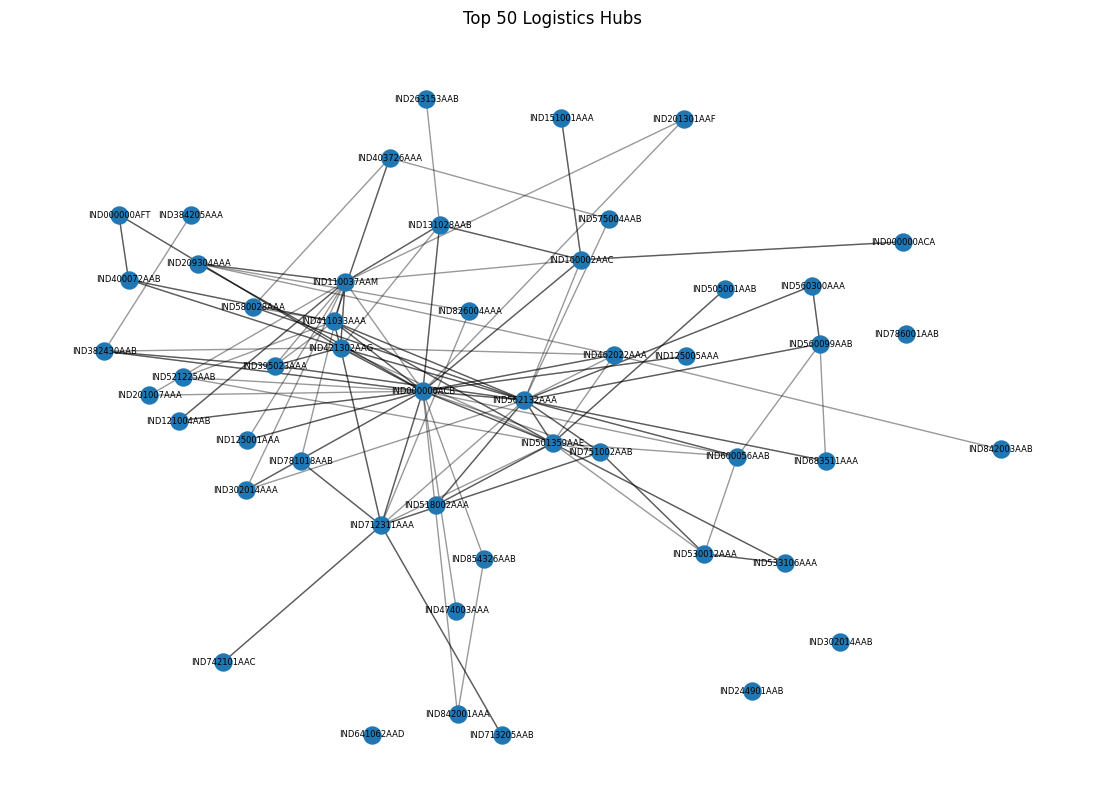

In [80]:
import matplotlib.pyplot as plt
import networkx as nx

top_nodes = sorted(
    G.degree,
    key=lambda x: x[1],
    reverse=True
)[:50]

top_nodes = [n for n, _ in top_nodes]

H = G.subgraph(top_nodes)

plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    H,
    seed=42,
    k=0.8
)

nx.draw_networkx_nodes(
    H,
    pos,
    node_size=150
)

nx.draw_networkx_edges(
    H,
    pos,
    alpha=0.4,
    arrows=False
)

nx.draw_networkx_labels(
    H,
    pos,
    font_size=6
)

plt.title("Top 50 Logistics Hubs")
plt.axis("off")
plt.show()

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

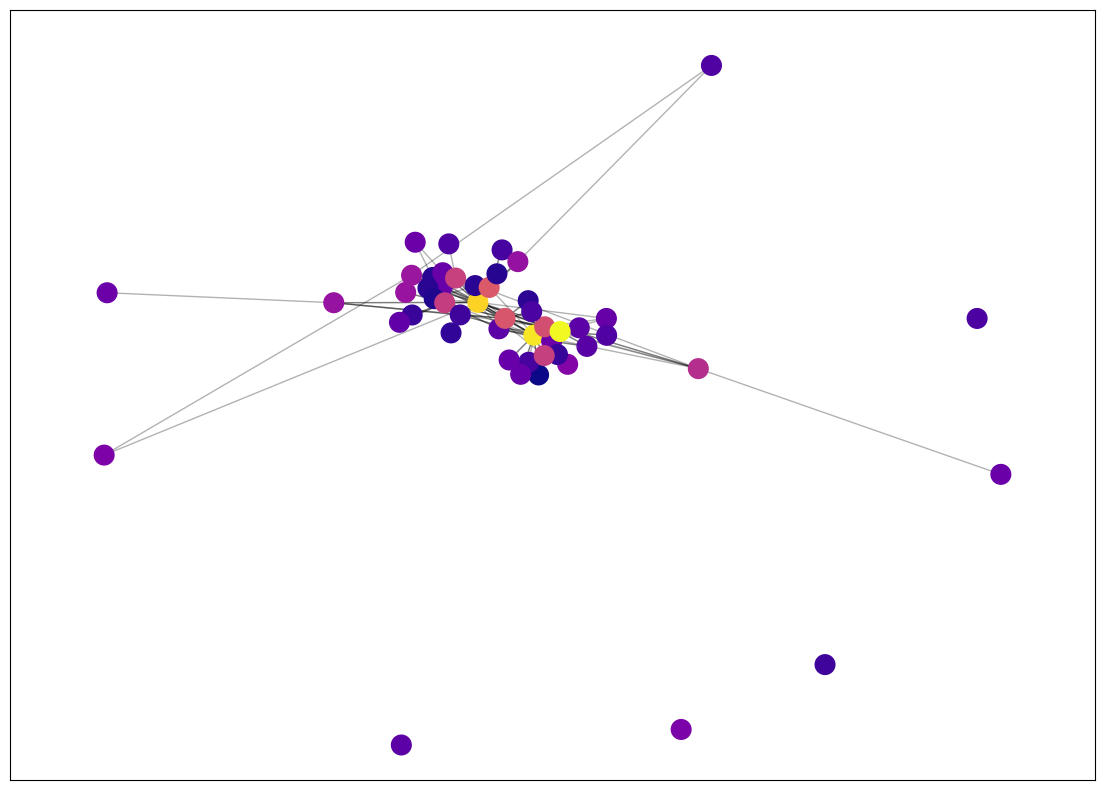

In [81]:
pagerank = nx.pagerank(G)

H = G.subgraph(top_nodes)

node_colors = [
    pagerank[n]
    for n in H.nodes()
]

plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    H,
    seed=42
)

nx.draw_networkx_nodes(
    H,
    pos,
    node_color=node_colors,
    node_size=200,
    cmap=plt.cm.plasma
)

nx.draw_networkx_edges(
    H,
    pos,
    alpha=0.3,
    arrows=False
)

plt.colorbar(
    plt.cm.ScalarMappable(
        cmap=plt.cm.plasma
    ),
    label="PageRank"
)

plt.axis("off")
plt.show()

In [82]:
print(
    edge_weights[
        ['source_center',
         'destination_center']
    ].drop_duplicates().shape[0]
)

print(
    G.number_of_edges()
)

2270
2270


In [83]:
largest_cc = max(
    nx.weakly_connected_components(G),
    key=len
)

print(len(largest_cc))
print(len(largest_cc) / G.number_of_nodes() * 100)

1175
76.24918883841661


In [84]:
isolated = list(nx.isolates(G))

print(f"Isolated hubs: {len(isolated)}")
print(isolated[:20])

Isolated hubs: 0
[]


In [85]:
degree_df = pd.DataFrame(
    dict(G.degree()).items(),
    columns=["hub", "degree"]
)

degree_df.sort_values(
    "degree"
).head(30)

,hub,degree
1072,IND600008AAA,1
1069,IND591126AAA,1
1054,IND583121AAA,1
1371,IND754142AAA,1
1370,IND754103AAA,1
62,IND000000ACK,1
1522,IND847404AAB,1
1519,IND845305AAA,1
1518,IND844101AAB,1
1517,IND847223AAA,1


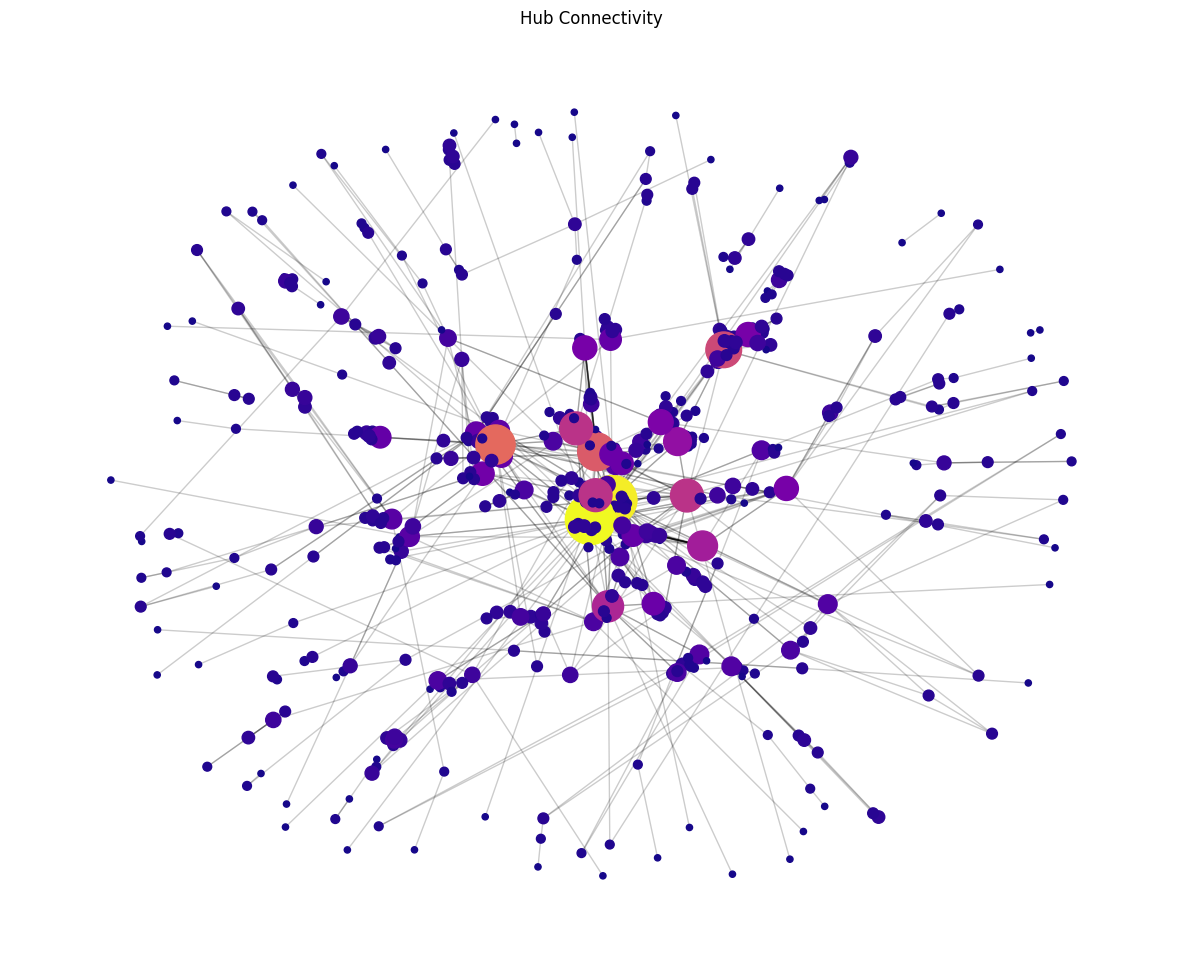

In [86]:
plt.figure(figsize=(15,12))

H = G.subgraph(
    [n for n, d in G.degree() if d >= 3]
)

pos = nx.spring_layout(H, seed=42)

node_sizes = [
    H.degree(n) * 20
    for n in H.nodes()
]

nx.draw_networkx_nodes(
    H,
    pos,
    node_size=node_sizes,
    node_color=node_sizes,
    cmap=plt.cm.plasma
)

nx.draw_networkx_edges(
    H,
    pos,
    alpha=0.2,
    arrows=False
)

plt.title("Hub Connectivity")
plt.axis("off")
plt.show()

In [87]:
audit_df.head(1)

,hub,betweenness,in_degree,out_degree,clustering,delayed_corridors,degree_ratio
0,IND000000AAL,0.0,1,1,0.0,2,0.5


The SLA risk score is a composite metric combining four 
structural graph features. Betweenness centrality is weighted 
at 0.4 as it is the primary driver of cascade failures. 
Remaining factors weighted equally at 0.2. Weights are 
domain-informed and can be tuned based on operational priorities.

In [90]:
from sklearn.preprocessing import MinMaxScaler

cols = ['betweenness', 'degree_ratio', 'delayed_corridors']

audit_df[[c + '_norm' for c in cols]] = (
    MinMaxScaler().fit_transform(audit_df[cols])
)

audit_df['clustering_risk'] = 1 - audit_df['clustering']

audit_df['sla_risk_score'] = (
      0.4 * audit_df['betweenness_norm']
    + 0.2 * audit_df['degree_ratio_norm']
    + 0.2 * audit_df['delayed_corridors_norm']
    + 0.2 * audit_df['clustering_risk']
)

audit_df['sla_rank'] = audit_df['sla_risk_score'].rank(ascending=False, method='min').astype(int)

print(audit_df.sort_values('sla_risk_score', ascending=False).head(10)[['hub','betweenness','in_degree','out_degree','clustering','delayed_corridors','sla_risk_score','sla_rank']])

             hub  betweenness  in_degree  out_degree  clustering  \
18  IND000000ACB     0.171864         40          46    0.039610   
7   IND562132AAA     0.098657         36          35    0.050170   
54  IND501359AAE     0.069917         29          26    0.041026   
57  IND712311AAA     0.072325         17          20    0.049231   
40  IND131028AAB     0.053066         18          17    0.031746   
17  IND160002AAC     0.038868         23          28    0.029487   
52  IND421302AAG     0.036328         25          27    0.058824   
56  IND600056AAB     0.038192         17          18    0.055336   
1   IND411033AAA     0.029236         21          19    0.062678   
50  IND382430AAB     0.034307         15          12    0.038961   

    delayed_corridors  sla_risk_score  sla_rank  
18                 85        0.834631         1  
7                  69        0.631936         2  
54                 55        0.537638         3  
57                 37        0.486019         4  
4

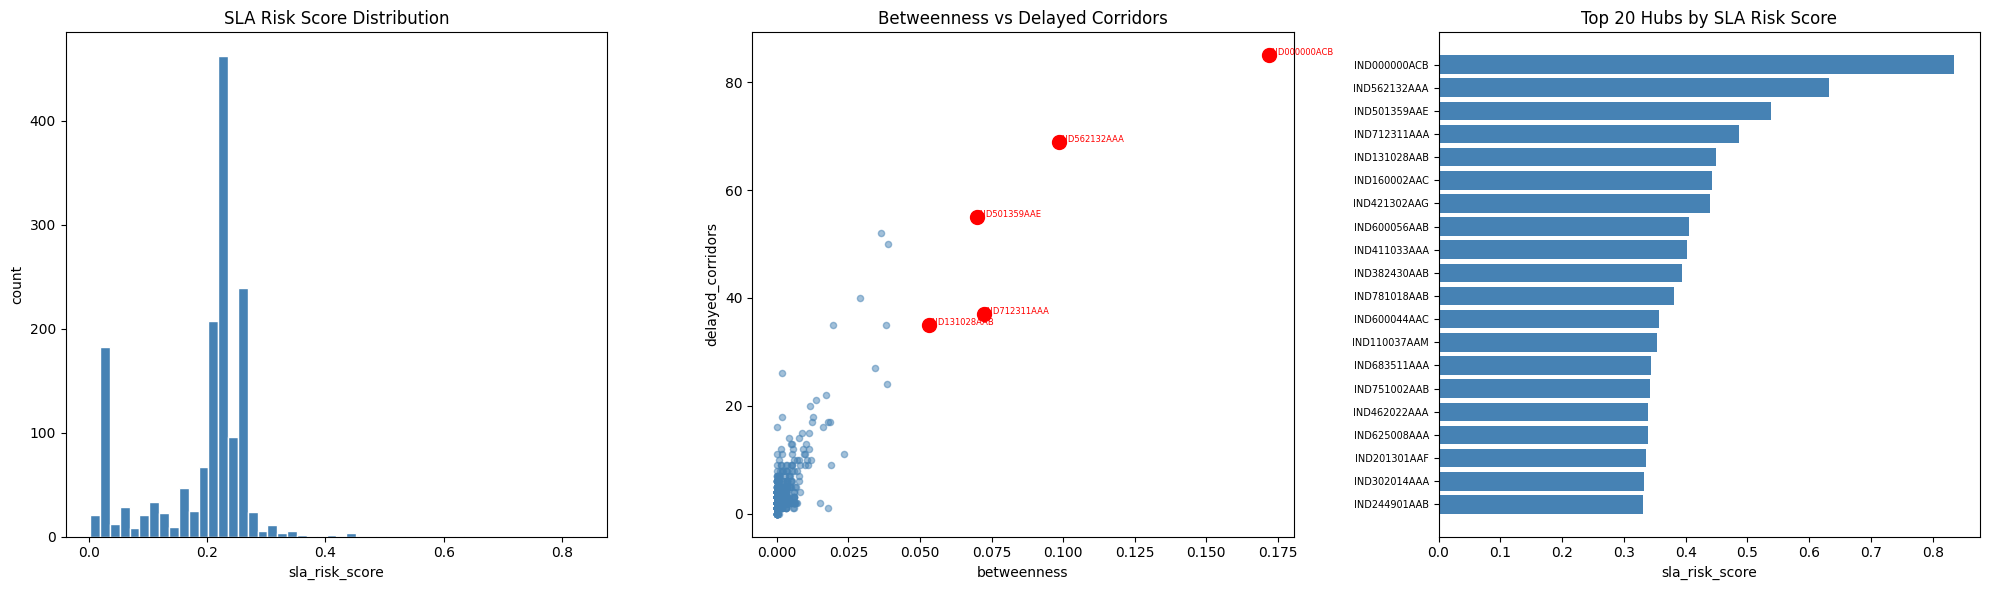

In [91]:
import matplotlib.pyplot as plt
import networkx as nx

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1 - SLA risk score distribution
axes[0].hist(audit_df['sla_risk_score'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SLA Risk Score Distribution')
axes[0].set_xlabel('sla_risk_score')
axes[0].set_ylabel('count')

# Plot 2 - Betweenness vs Delayed Corridors
axes[1].scatter(
    audit_df['betweenness'],
    audit_df['delayed_corridors'],
    alpha=0.5, color='steelblue', s=20
)
top5 = audit_df.nlargest(5, 'sla_risk_score')
axes[1].scatter(
    top5['betweenness'],
    top5['delayed_corridors'],
    color='red', s=100, zorder=5
)
for _, row in top5.iterrows():
    axes[1].annotate(
        row['hub'],
        (row['betweenness'], row['delayed_corridors']),
        fontsize=6, color='red'
    )
axes[1].set_title('Betweenness vs Delayed Corridors')
axes[1].set_xlabel('betweenness')
axes[1].set_ylabel('delayed_corridors')

# Plot 3 - Top 20 hubs by SLA risk score
top20 = audit_df.nlargest(20, 'sla_risk_score')
axes[2].barh(
    range(20),
    top20['sla_risk_score'].values,
    color='steelblue'
)
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(top20['hub'].values, fontsize=7)
axes[2].invert_yaxis()
axes[2].set_title('Top 20 Hubs by SLA Risk Score')
axes[2].set_xlabel('sla_risk_score')

plt.tight_layout()
plt.show()

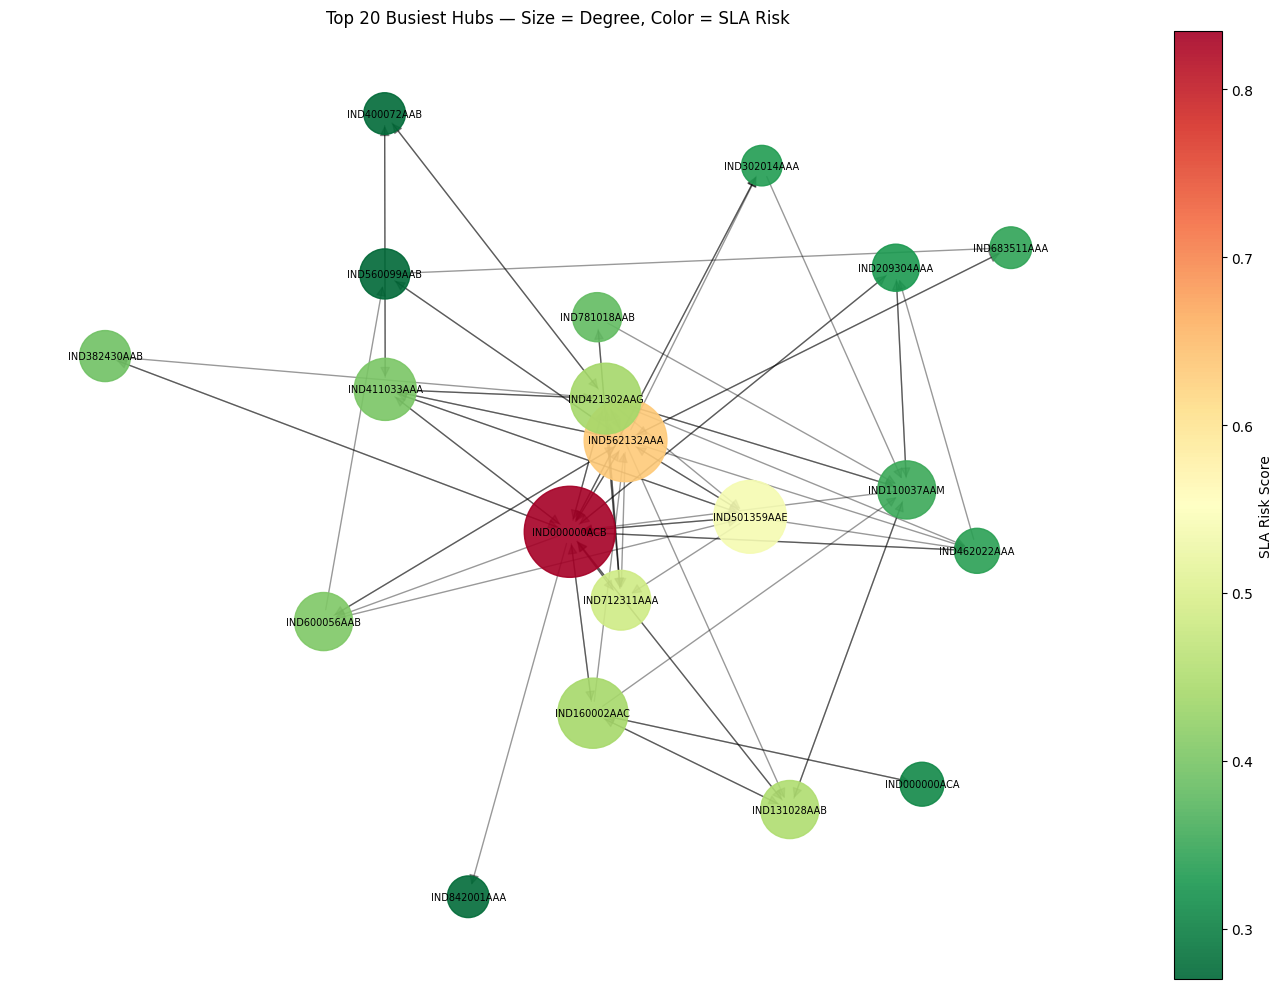

In [ ]:

top20_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:20]
top20_nodes = [n for n, _ in top20_nodes]
H_top = G.subgraph(top20_nodes)

pos_top = nx.spring_layout(H_top, seed=42, k=1.5)
node_sizes_top = [G.degree(n) * 50 for n in H_top.nodes()]
node_colors_top = [audit_df[audit_df['hub'] == n]['sla_risk_score'].values[0] for n in H_top.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
nodes = nx.draw_networkx_nodes(H_top, pos_top, node_size=node_sizes_top, node_color=node_colors_top, cmap=plt.cm.RdYlGn_r, alpha=0.9, ax=ax)
nx.draw_networkx_edges(H_top, pos_top, alpha=0.4, arrows=True, arrowsize=15, ax=ax)
nx.draw_networkx_labels(H_top, pos_top, font_size=7, font_color='black', ax=ax)
plt.colorbar(nodes, ax=ax, label='SLA Risk Score')
ax.set_title('Top 20 Busiest Hubs — Size = Degree, Color = SLA Risk')
ax.axis('off')
plt.tight_layout()
plt.show()

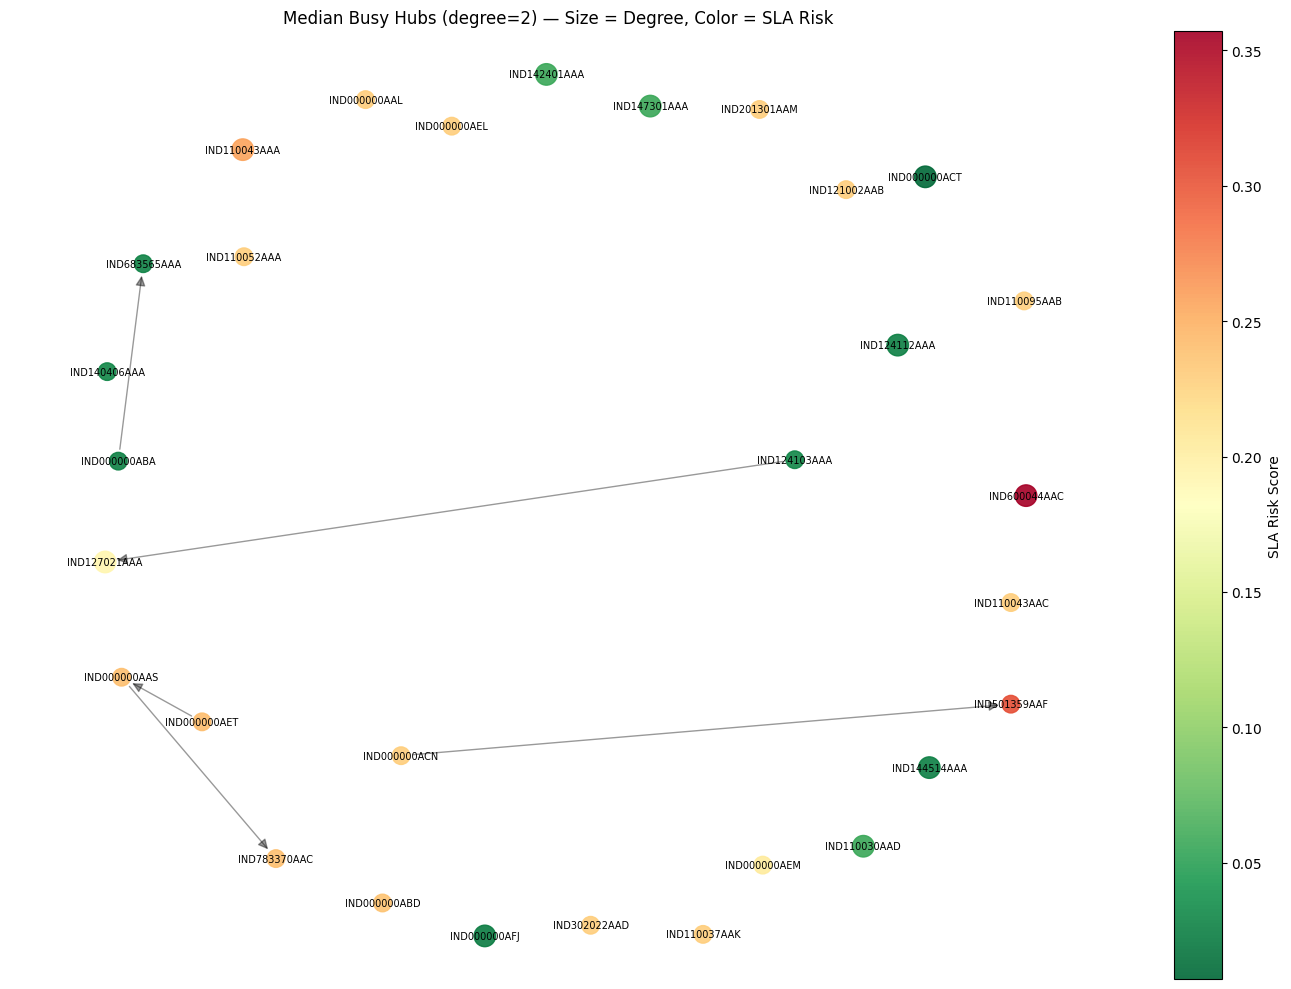

Median degree: 2
Nodes shown: 30


In [95]:
degrees = dict(G.degree())
all_degrees = sorted(degrees.values())
median_degree = int(np.median(all_degrees))

median_nodes = [n for n, d in G.degree() if d == median_degree or d == median_degree + 1][:30]
H_mid = G.subgraph(median_nodes)

pos_mid = nx.spring_layout(H_mid, seed=42, k=1.5)
node_sizes_mid = [G.degree(n) * 80 for n in H_mid.nodes()]
node_colors_mid = [audit_df[audit_df['hub'] == n]['sla_risk_score'].values[0] for n in H_mid.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
nodes = nx.draw_networkx_nodes(H_mid, pos_mid, node_size=node_sizes_mid, node_color=node_colors_mid, cmap=plt.cm.RdYlGn_r, alpha=0.9, ax=ax)
nx.draw_networkx_edges(H_mid, pos_mid, alpha=0.4, arrows=True, arrowsize=15, ax=ax)
nx.draw_networkx_labels(H_mid, pos_mid, font_size=7, font_color='black', ax=ax)
plt.colorbar(nodes, ax=ax, label='SLA Risk Score')
ax.set_title(f'Median Busy Hubs (degree={median_degree}) — Size = Degree, Color = SLA Risk')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Median degree: {median_degree}')
print(f'Nodes shown: {len(median_nodes)}')

In [ ]:
import pickle

audit_df.to_parquet('../data/processed/audit_df.parquet')

with open('../data/processed/graph.pkl', 'wb') as f:
    pickle.dump(G, f)

print('audit_df saved')
print('Graph saved')

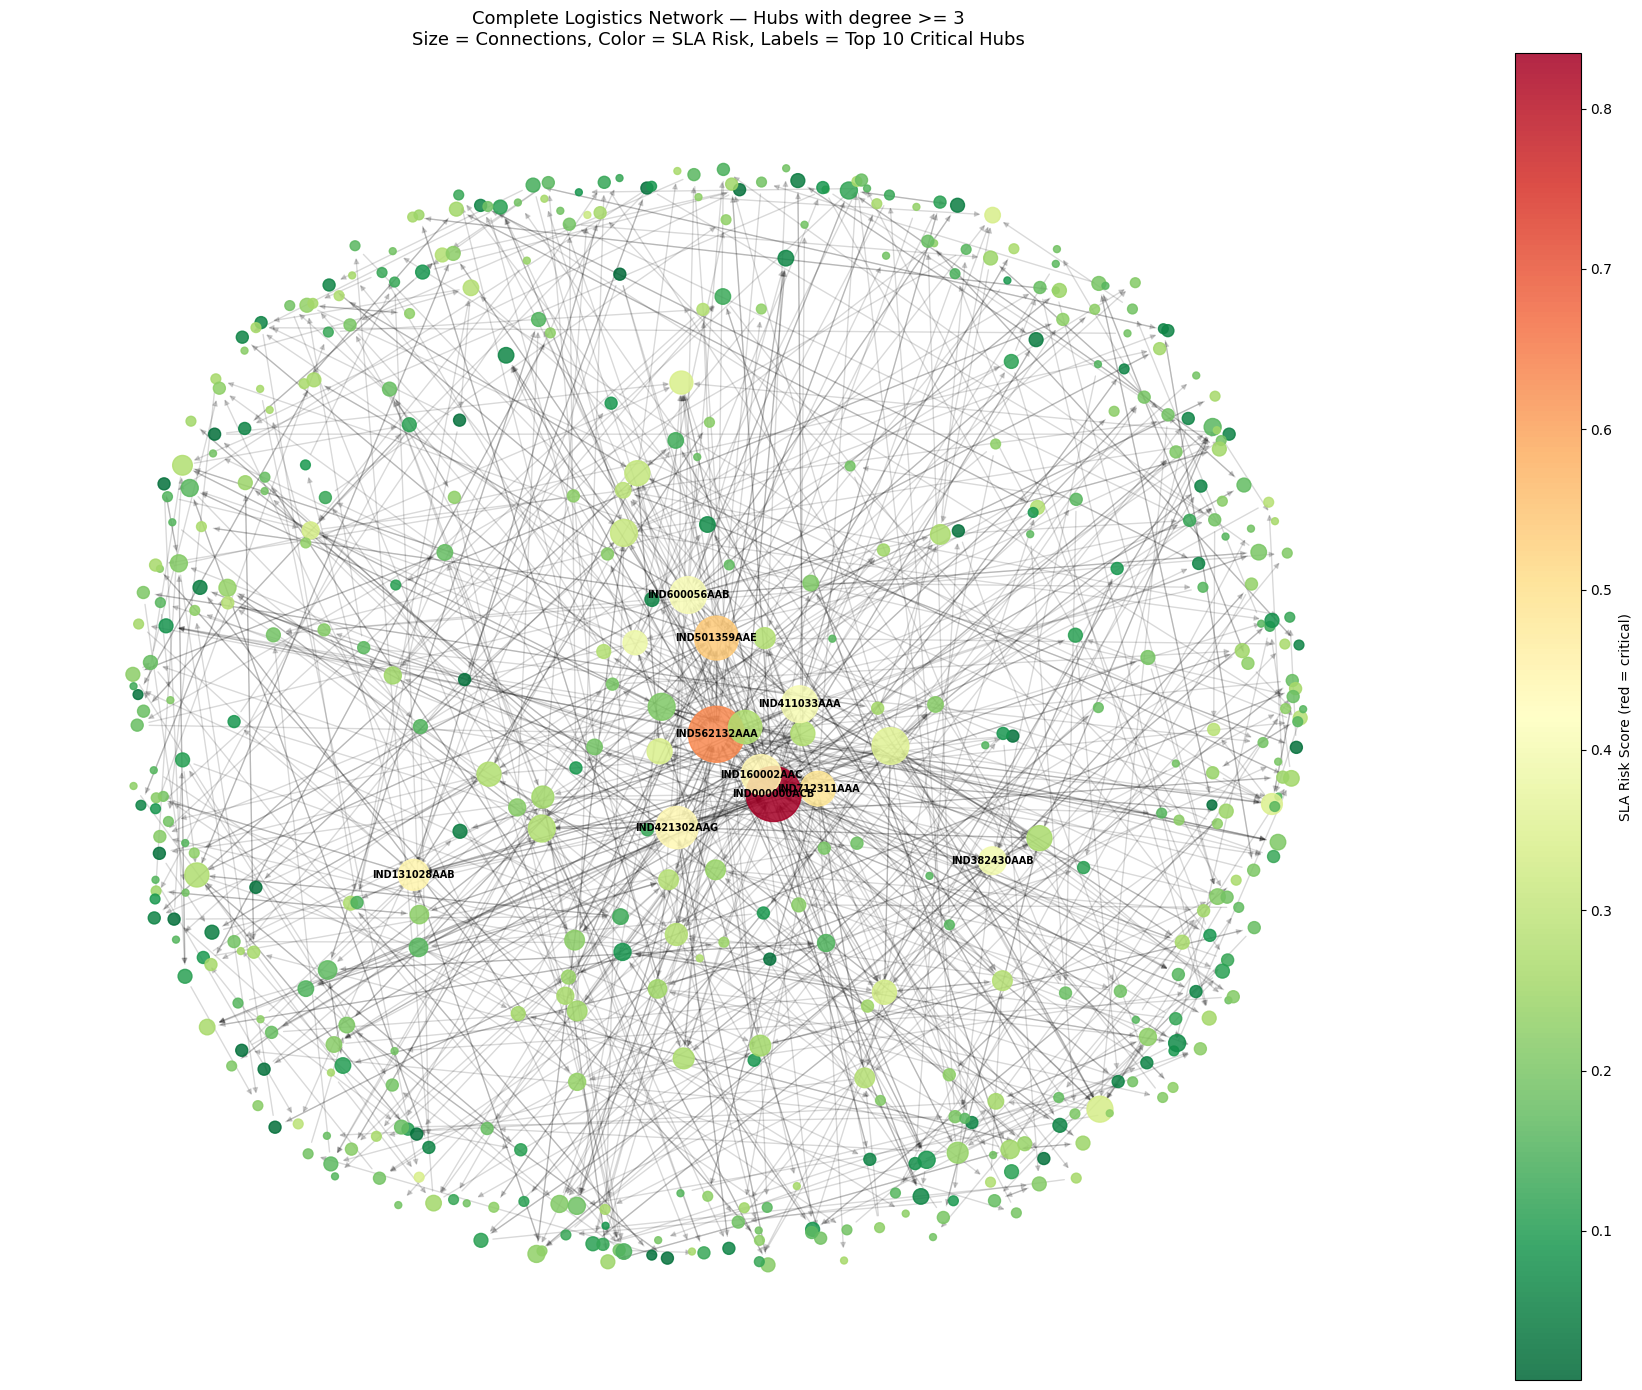

Hubs shown: 488
Edges shown: 956


In [96]:
H_full = G.subgraph([n for n, d in G.degree() if d >= 3])

pos = nx.spring_layout(H_full, seed=42, k=0.8)

node_sizes = [H_full.degree(n) * 25 for n in H_full.nodes()]
node_colors = [
    audit_df[audit_df['hub'] == n]['sla_risk_score'].values[0] 
    if len(audit_df[audit_df['hub'] == n]) > 0 else 0 
    for n in H_full.nodes()
]

fig, ax = plt.subplots(figsize=(18, 14))

nodes = nx.draw_networkx_nodes(
    H_full, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.RdYlGn_r,
    alpha=0.85,
    ax=ax
)

nx.draw_networkx_edges(
    H_full, pos,
    alpha=0.15,
    arrows=True,
    arrowsize=8,
    ax=ax
)

top10 = audit_df.nlargest(10, 'sla_risk_score')['hub'].tolist()
top10_pos = {n: pos[n] for n in top10 if n in pos}
nx.draw_networkx_labels(
    H_full.subgraph(top10),
    top10_pos,
    font_size=7,
    font_color='black',
    font_weight='bold',
    ax=ax
)

plt.colorbar(nodes, ax=ax, label='SLA Risk Score (red = critical)')
ax.set_title('Complete Logistics Network — Hubs with degree >= 3\nSize = Connections, Color = SLA Risk, Labels = Top 10 Critical Hubs', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Hubs shown: {H_full.number_of_nodes()}')
print(f'Edges shown: {H_full.number_of_edges()}')

In [97]:
import pickle

audit_df.to_parquet('../data/processed/audit_df.parquet')
edge_weights.to_parquet('../data/processed/edge_weights.parquet')

with open('../data/processed/graph.pkl', 'wb') as f:
    pickle.dump(G, f)

print(f'audit_df saved: {audit_df.shape}')
print(f'edge_weights saved: {edge_weights.shape}')
print(f'Graph saved: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

audit_df saved: (1541, 13)
edge_weights saved: (3141, 5)
Graph saved: 1541 nodes, 2270 edges


## Saved Artifacts

| Artifact               | Purpose                                                                                                                                      |
| ---------------------- | -------------------------------------------------------------------------------------------------------------------------------------------- |
| `audit_df.parquet`     | Hub-level centrality metrics, bottleneck indicators, and SLA risk scores. Used for dashboarding, network audits, and the strategy memo.      |
| `edge_weights.parquet` | Cleaned corridor-level delay weights between hubs. Used as edge features for graph representation learning.                                  |
| `network_graph.pkl`    | Serialized NetworkX graph containing hubs, corridors, node features, and edge weights. Used for Node2Vec and GraphSAGE embedding generation. |
